# **Point Net - Classification**

In [1]:
import os
import re
from glob import glob
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchmetrics
from torchmetrics.classification import MulticlassMatthewsCorrCoef
import open3d as o3

from open3d.web_visualizer import draw # for non Colab
import os, os.path as osp

import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
[Open3D INFO] Resetting default logger to print to terminal.


In [2]:
NUM_TRAIN_POINTS = 2500
NUM_TEST_POINTS = 10000
NUM_CLASSES = 16
GLOBAL_FEATS = 1024
BATCH_SIZE = 32

            
ROOT = osp.abspath("shapenet_like_out")

In [3]:
from torch.utils.data import DataLoader
from UTILS.foil_dataset import convert_to_shapenet_like

npoints = 10000
convert_to_shapenet_like(root_out = "shapenet_like_out3",npoints=npoints, manifest_keys = ["full_train","full_test"]) # the full train set
# convert_to_shapenet_like(root_out = "shapenet_like_out2", npoints=npoints, manifest_key = "full_test") # the full test set

Converting to ShapeNet-like:   0%|          | 0/1000 [00:00<?, ?it/s]


KeyboardInterrupt: 

In [8]:
from UTILS.foil_dataset import create_extra_category_from_existing
create_extra_category_from_existing(
    root_out="shapenet_like_out3",
    from_category_id="00000000",
    new_category_id="11111111",
    new_category_name="centered",
    transform_mode="centered"
)



=== Création catégorie centered (11111111) ===


Transforming centered: 100%|██████████| 1000/1000 [00:48<00:00, 20.48it/s]

[OK] Ajouté 1000 tokens dans test split.


In [9]:
from UTILS.foil_dataset import create_extra_category_from_existing
create_extra_category_from_existing(
    root_out="shapenet_like_out3",
    from_category_id="00000000",
    new_category_id="22222222",
    new_category_name="normalized",
    transform_mode="normalized"
)



=== Création catégorie normalized (22222222) ===


Transforming normalized: 100%|██████████| 1000/1000 [01:11<00:00, 14.08it/s]

[OK] Ajouté 1000 tokens dans test split.


In [10]:
from UTILS.foil_dataset import create_extra_category_extruded

create_extra_category_extruded(
    root_out="shapenet_like_out3",
    from_category_id="00000000",
    new_category_id="44444444",
    new_category_name="default_Extruded",
    thickness=1.0,
    k_layers=3
)



=== Création catégorie extrudée default_Extruded (44444444) ===


Extruding default_Extruded: 100%|██████████| 1000/1000 [01:21<00:00, 12.29it/s]

[OK] Ajouté 1000 objets extrudés au test split.


In [11]:
from UTILS.foil_dataset import create_extra_category_extruded
create_extra_category_extruded(
    root_out="shapenet_like_out3",
    from_category_id="11111111",
    new_category_id="55555555",
    new_category_name="centered_Extruded",
    thickness=1.0,
    k_layers=3
)



=== Création catégorie extrudée centered_Extruded (55555555) ===


Extruding centered_Extruded: 100%|██████████| 1000/1000 [01:49<00:00,  9.12it/s]

[OK] Ajouté 1000 objets extrudés au test split.


In [12]:
create_extra_category_extruded(
    root_out="shapenet_like_out3",
    from_category_id="22222222",
    new_category_id="66666666",
    new_category_name="normalized_Extruded",
    thickness=1.0,
    k_layers=3
)


=== Création catégorie extrudée normalized_Extruded (66666666) ===


Extruding normalized_Extruded: 100%|██████████| 1000/1000 [02:16<00:00,  7.32it/s]

[OK] Ajouté 1000 objets extrudés au test split.


Generating torus: 100%|██████████| 1000/1000 [00:50<00:00, 19.67it/s]


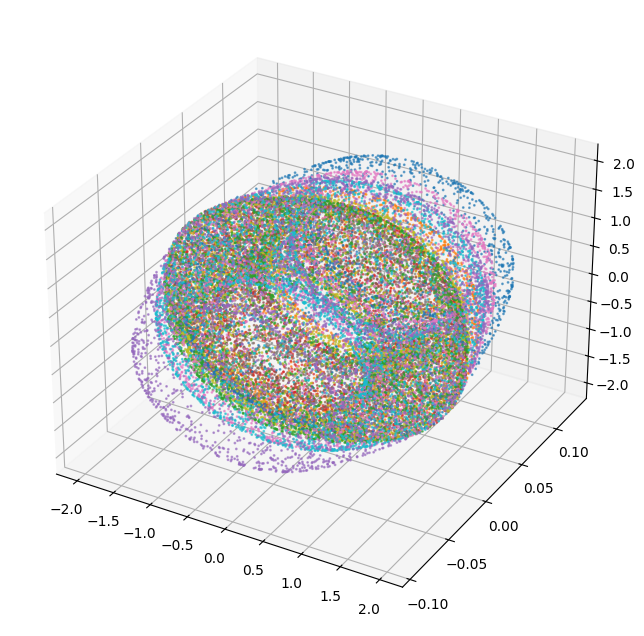

[OK] Torus surface generation complete.


In [9]:
from UTILS.foil_dataset import create_extra_category_torus
create_extra_category_torus(
    root_out="shapenet_like_out3",
    from_category_id="00000000",
    new_category_id="70707070",
    new_category_name="torus_default",
    visualize=True,
    visualize_n=10
)


Generating torus: 100%|██████████| 1000/1000 [01:16<00:00, 13.14it/s]


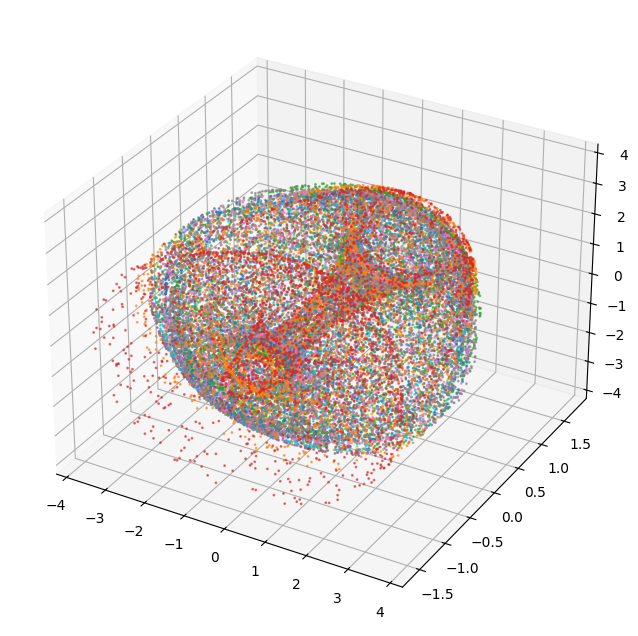

[OK] Torus surface generation complete.


In [12]:
from UTILS.foil_dataset import create_extra_category_torus
create_extra_category_torus(
    root_out="shapenet_like_out3",
    from_category_id="22222222",
    new_category_id="80808080",
    new_category_name="torus_normalized",
    visualize=True,
    visualize_n=10,
    R_major = 2
)


In [1]:
from UTILS.foil_dataset import create_extra_category_extruded

create_extra_category_extruded(
    root_out="shapenet_like_out3",
    from_category_id="00000000",
    new_category_id="88888888",
    new_category_name="default_Extruded_thin",
    thickness=0.1,
    k_layers=3
)



=== Création catégorie extrudée default_Extruded_thin (88888888) ===


Extruding default_Extruded_thin: 100%|██████████| 1000/1000 [04:46<00:00,  3.49it/s]

[OK] Ajouté 1000 objets extrudés au test split.


In [1]:
from UTILS.foil_dataset import create_extra_category_extruded
create_extra_category_extruded(
    root_out="shapenet_like_out3",
    from_category_id="11111111",
    new_category_id="99999999",
    new_category_name="centered_Extruded_thin",
    thickness=0.1,
    k_layers=3
)


ModuleNotFoundError: No module named 'point_netANDpoint_MAE'

In [3]:
create_extra_category_extruded(
    root_out="shapenet_like_out3",
    from_category_id="22222222",
    new_category_id="10101010",
    new_category_name="normalized_Extruded_thin",
    thickness=0.1,
    k_layers=3
)


=== Création catégorie extrudée normalized_Extruded_thin (10101010) ===


Extruding normalized_Extruded_thin: 100%|██████████| 1000/1000 [05:15<00:00,  3.17it/s]

[OK] Ajouté 1000 objets extrudés au test split.


In [3]:
from UTILS.foil_dataset import create_extra_category_extruded_solid

create_extra_category_extruded_solid(
    root_out="shapenet_like_out3",
    from_category_id="00000000",
    new_category_id="50505050",
    new_category_name="Extruded_default_thin_uniform",
    thickness=0.05,
)


=== Création catégorie VOLUMIQUE Extruded_default_thin_uniform (50505050) ===


Extruding solid Extruded_default_thin_uniform: 100%|██████████| 1000/1000 [01:13<00:00, 13.53it/s]

[OK] Ajouté 1000 objets SOLIDES au test split.


In [4]:
from UTILS.foil_dataset import create_extra_category_extruded_solid

create_extra_category_extruded_solid(
    root_out="shapenet_like_out3",
    from_category_id="22222222",
    new_category_id="60606060",
    new_category_name="Extruded_normalized_thin_uniform",
    thickness=0.05,
)


=== Création catégorie VOLUMIQUE Extruded_normalized_thin_uniform (60606060) ===


Extruding solid Extruded_normalized_thin_uniform: 100%|██████████| 1000/1000 [01:29<00:00, 11.19it/s]

[OK] Ajouté 1000 objets SOLIDES au test split.


In [1]:
import joblib
import numpy as np
from UTILS.foil_dataset import create_extra_category_OT
# --- Load pretrained GMM ---
gmm = joblib.load("gmm_pretrain_xyz.pkl")
print("[OK] GMM loaded")

# --- Generate reference cloud ---
X_ref, _ = gmm.sample(15000)

# --- Save as .pts file ---
np.savetxt("gmm_reference_cloud.pts", X_ref, fmt="%.6f")
print("[OK] Saved as .pts:", X_ref.shape)


[OK] GMM loaded
[OK] Saved as .pts: (15000, 3)


In [2]:


# --- Load pretrained GMM ---
gmm = joblib.load("gmm_pretrain_xyz.pkl")
print("[OK] GMM loaded")

# --- Generate reference cloud ---
X_ref, _ = gmm.sample(15000)

# --- Save as .pts file ---
np.savetxt("gmm_reference_cloud.pts", X_ref, fmt="%.6f")
print("[OK] Saved as .pts:", X_ref.shape)




[OK] GMM loaded
[OK] Saved as .pts: (15000, 3)


In [3]:
# --- Apply OT ---
create_extra_category_OT(
    root_out="shapenet_like_out3",
    from_category_id="50505050",
    new_category_id="90909090",
    new_category_name="OT_3D",
    gmm_reference_path="gmm_reference_cloud.pts",  # If your function accepts .pts
    reg=0.05,
)


=== Création catégorie OT FAST OT_3D (90909090) ===


OT Sinkhorn (fast): 100%|██████████| 1000/1000 [00:46<00:00, 21.48it/s]

[OK] Ajouté 1000 objets OT (FAST) au test split.


In [4]:
# --- Apply OT ---
create_extra_category_OT(
    root_out="shapenet_like_out3",
    from_category_id="00000000",
    new_category_id="40404040",
    new_category_name="OT_2D",
    gmm_reference_path="gmm_reference_cloud.pts",  # If your function accepts .pts
    reg=0.05,
)



=== Création catégorie OT FAST OT_2D (40404040) ===


OT Sinkhorn (fast): 100%|██████████| 1000/1000 [00:50<00:00, 19.73it/s]

[OK] Ajouté 1000 objets OT (FAST) au test split.
